In [18]:
import pandas as pd
df_tx = pd.read_csv('./data/transcriptomics.csv', index_col=0)

df_tx = df_tx.pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df_px = pd.read_csv('./data/proteomics.csv', index_col=0)

df_px = df_px.pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df = pd.read_csv('./data/cytof.csv', index_col=0)

df_p = df[df['simulationConditionId'].str.split('__').str[1]=='EGF'].pivot_table(
    index='preequilibrationConditionId', columns='FEATURE_ID', values='measurement'
)

df_tx.index = [f't{m}' for m in df_tx.index]
df_px.index = [f'p{m}' for m in df_px.index]

df = pd.concat([df_p, df_tx.T, df_px.T], axis=1)

In [19]:
import numpy as np
def nancorr(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if np.sum(mask) < 30:
        return np.nan
    return np.corrcoef(a[mask], b[mask])[0, 1]

corrs ={
    m : {
    col: nancorr(df[m], df[col])
    for col in df.columns if col != m
    } for m in ('p.p90RSK', 'p.ERK', 'p.p38')
}

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [20]:
corrs = pd.DataFrame(corrs)
corrs

,p.p90RSK,p.ERK,p.p38
CyclinB,0.257196,0.109019,0.312650
GAPDH,0.128621,0.183306,0.142763
IdU,0.268101,0.121765,0.223139
Ki.67,0.172188,0.018894,0.174319
b.CATENIN,-0.054686,0.011227,0.023144
...,...,...,...
pZWINT,0.318603,0.176271,0.306542
pZYG11B,-0.067734,-0.085957,0.075806
pZYX,0.423460,0.463635,0.353236
pZZEF1,-0.162998,-0.088790,-0.335486


In [21]:
corrs.sort_values('p.p90RSK', ascending=True)

,p.p90RSK,p.ERK,p.p38
pRHOT2,-0.642628,-0.437499,-0.625449
tRNF41,-0.631521,-0.563600,-0.521199
tCCDC78,-0.614209,-0.580141,-0.607062
tFAHD1,-0.604768,-0.391325,-0.561114
tKIAA1257,-0.584236,-0.529737,-0.658800
...,...,...,...
pZNF652,NaN,NaN,NaN
pZNF664,NaN,NaN,NaN
pZNF703,NaN,NaN,NaN
pZNRF1,NaN,NaN,NaN


In [22]:
df[corrs.index[:20]]

,CyclinB,GAPDH,IdU,Ki.67,b.CATENIN,cleavedCas,p.4EBP1,p.AKT.Thr308.,p.AMPK,p.Akt.Ser473.,p.BTK,p.CREB,p.ERK,p.FAK,p.GSK3b,p.H3,p.HER2,p.JNK,p.MAP2K3,p.MAPKAPK2
preequilibrationConditionId,,,,,,,,,,,,,,,,,,,,
c184A1,1.947373,3.052297,5.107729,2.394946,1.212711,2.515484,1.933219,2.444833,3.471868,2.475011,2.431561,0.795845,3.262251,1.895357,2.014180,3.554504,4.471969,1.864154,1.426738,1.833043
c184B5,1.957547,2.311961,5.958760,2.255738,0.884221,2.748893,2.553389,2.322446,3.593913,3.103394,2.971962,0.776905,3.043229,2.034005,2.222365,3.502732,4.776246,1.813406,1.426818,1.919293
cBT20,2.288187,2.228066,6.284131,2.814255,0.931947,2.182001,2.897757,2.525881,3.267079,4.466884,2.507831,1.329303,4.109490,2.423212,4.145026,2.949211,5.384618,1.791538,1.716520,2.710060
cBT474,1.828055,2.721244,6.125910,2.436720,0.998466,2.338102,2.587156,2.689460,2.548652,3.844061,2.607510,0.995234,3.157603,1.865693,3.716484,2.759757,4.890003,2.064395,1.411224,2.594263
cBT483,2.003603,2.018609,7.331352,2.674595,1.038493,1.658971,2.338835,2.040013,2.703117,3.922285,2.461487,0.582553,3.233732,1.474401,3.037255,2.238729,NaN,1.318932,1.324188,2.113743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cMDAMB436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cZR75B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cHCC2157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df[corrs.index[:20]]

,CyclinB,GAPDH,IdU,Ki.67,b.CATENIN,cleavedCas,p.4EBP1,p.AKT.Thr308.,p.AMPK,p.Akt.Ser473.,p.BTK,p.CREB,p.ERK,p.FAK,p.GSK3b,p.H3,p.HER2,p.JNK,p.MAP2K3,p.MAPKAPK2
preequilibrationConditionId,,,,,,,,,,,,,,,,,,,,
c184A1,1.947373,3.052297,5.107729,2.394946,1.212711,2.515484,1.933219,2.444833,3.471868,2.475011,2.431561,0.795845,3.262251,1.895357,2.014180,3.554504,4.471969,1.864154,1.426738,1.833043
c184B5,1.957547,2.311961,5.958760,2.255738,0.884221,2.748893,2.553389,2.322446,3.593913,3.103394,2.971962,0.776905,3.043229,2.034005,2.222365,3.502732,4.776246,1.813406,1.426818,1.919293
cBT20,2.288187,2.228066,6.284131,2.814255,0.931947,2.182001,2.897757,2.525881,3.267079,4.466884,2.507831,1.329303,4.109490,2.423212,4.145026,2.949211,5.384618,1.791538,1.716520,2.710060
cBT474,1.828055,2.721244,6.125910,2.436720,0.998466,2.338102,2.587156,2.689460,2.548652,3.844061,2.607510,0.995234,3.157603,1.865693,3.716484,2.759757,4.890003,2.064395,1.411224,2.594263
cBT483,2.003603,2.018609,7.331352,2.674595,1.038493,1.658971,2.338835,2.040013,2.703117,3.922285,2.461487,0.582553,3.233732,1.474401,3.037255,2.238729,NaN,1.318932,1.324188,2.113743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cMDAMB436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cZR75B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cHCC2157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
corrs

,p.p90RSK,p.ERK,p.p38
CyclinB,0.257196,0.109019,0.312650
GAPDH,0.128621,0.183306,0.142763
IdU,0.268101,0.121765,0.223139
Ki.67,0.172188,0.018894,0.174319
b.CATENIN,-0.054686,0.011227,0.023144
...,...,...,...
pZWINT,0.318603,0.176271,0.306542
pZYG11B,-0.067734,-0.085957,0.075806
pZYX,0.423460,0.463635,0.353236
pZZEF1,-0.162998,-0.088790,-0.335486


In [25]:
from scipy import stats
def nancorr_p(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if np.sum(mask) < 30:
        return np.nan
    return stats.pearsonr(a[mask], b[mask])[1]

In [26]:
nancorr_p(df['p.p90RSK'], df['pRAB12'])

np.float64(1.4406427571678838e-06)

In [27]:
df_p.columns

Index(['CyclinB', 'GAPDH', 'IdU', 'Ki.67', 'b.CATENIN', 'cleavedCas',
       'p.4EBP1', 'p.AKT.Thr308.', 'p.AMPK', 'p.Akt.Ser473.', 'p.BTK',
       'p.CREB', 'p.ERK', 'p.FAK', 'p.GSK3b', 'p.H3', 'p.HER2', 'p.JNK',
       'p.MAP2K3', 'p.MAPKAPK2', 'p.MEK', 'p.MKK3.MKK6', 'p.MKK4', 'p.NFkB',
       'p.PDPK1', 'p.PLCg2', 'p.RB', 'p.S6', 'p.S6K', 'p.SMAD23', 'p.SRC',
       'p.STAT1', 'p.STAT3', 'p.STAT5', 'p.p38', 'p.p53', 'p.p90RSK'],
      dtype='object', name='FEATURE_ID')

In [28]:
pcorrs ={
    m : {
    col: nancorr_p(df[m], df[col])
    for col in df.columns if col != m
    } for m in ('p.p90RSK', 'p.ERK', 'p.p38')
}

/var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_35644/196763736.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return stats.pearsonr(a[mask], b[mask])[1]


In [29]:
pcorrs = pd.DataFrame(pcorrs)
pcorrs

,p.p90RSK,p.ERK,p.p38
CyclinB,0.065668,4.416963e-01,2.403014e-02
GAPDH,0.363489,1.933417e-01,3.126687e-01
IdU,0.054650,3.898332e-01,1.118156e-01
Ki.67,0.222229,8.942333e-01,2.164728e-01
b.CATENIN,0.700203,9.370382e-01,8.706284e-01
...,...,...,...
pZWINT,0.025672,2.256809e-01,3.217192e-02
pZYG11B,0.643775,5.570324e-01,6.046739e-01
pZYX,0.001760,5.369066e-04,1.020834e-02
pZZEF1,0.248268,5.313490e-01,1.504333e-02


<Axes: >

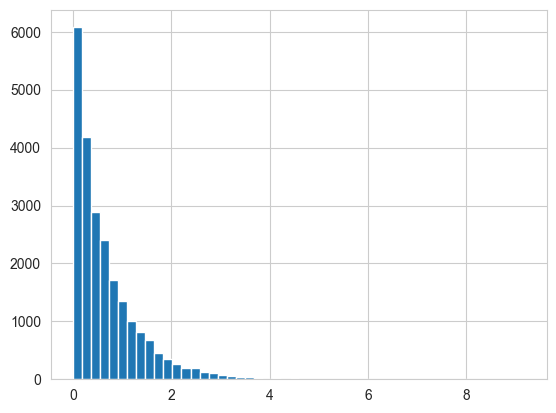

In [30]:
from scipy.stats import false_discovery_control
pcorrs['p.p90RSK'].apply(lambda p: -np.log10(p)).hist(bins=50)

In [31]:
df_fin = pcorrs['p.p90RSK'].loc[np.isfinite(pcorrs['p.p90RSK'].values)]
pval = pd.Series(false_discovery_control(df_fin), index=df_fin.index)
pval[pval < 0.05].sort_values()

p.ERK       0.000015
p.p38       0.000031
p.S6K       0.000040
p.MKK4      0.000273
pRHOT2      0.001296
              ...   
pMRPL57     0.048519
tTMEM63C    0.048577
tCNN3       0.048577
pMRPL16     0.048577
tCHST8      0.049889
Length: 110, dtype: float64

In [32]:
pcorrs['p.p90RSK'].max(
)

np.float64(0.999963186229898)

In [33]:
!pip install gseapy


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [46]:
import gseapy as gp
sets = ['GO_Biological_Process_2025', 'GO_Cellular_Component_2025', 'GO_Molecular_Function_2025', 'MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'MSigDB_Computational', 'MSigDB_Oncogenic_Signatures', 'Reactome_Pathways_2024', 'WikiPathway_2023_Human']
gl_t = [g[1:] for g in pval[pval < 0.05].index if g.startswith('t')]
bg_t = [g[1:] for g in pval.index if g.startswith('t')]
enr_tx = gp.enrichr(
    gene_list=gl_t,
    gene_sets=sets,
    organism='human',
    background=bg_t,
    outdir=None,
)
enr_tx.results.sort_values('Adjusted P-value', ascending=True)

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
655,MSigDB_Hallmark_2020,KRAS Signaling Up,0.000047,0.000936,0,0,10.444873,104.131137,PIGR;GPRC5B;LIF;ETS1;ETV4;CTSS
556,GO_Molecular_Function_2025,Metalloendopeptidase Inhibitor Activity (GO:00...,0.000011,0.001082,0,0,91.222222,1042.097305,RARRES1;TIMP2;RECK
656,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,0.000485,0.004850,0,0,8.489758,64.788310,GLIPR2;LIF;MAP3K8;ETV4;TGM2
474,GO_Cellular_Component_2025,Tertiary Granule Lumen (GO:1904724),0.000607,0.049760,0,0,20.228395,149.837236,TIMP2;QSOX1;CTSS
475,GO_Cellular_Component_2025,Tertiary Granule (GO:0070820),0.001540,0.052854,0,0,8.781671,56.871194,RCAN1;TIMP2;QSOX1;CTSS
...,...,...,...,...,...,...,...,...,...
1271,Reactome_Pathways_2024,RNA Polymerase II Transcription,0.937648,0.958394,0,0,0.440836,0.028381,ZSCAN32;TRIAP1
1272,Reactome_Pathways_2024,Cellular Responses to Stimuli,0.941580,0.958394,0,0,0.349343,0.021029,ETS1
1273,Reactome_Pathways_2024,Gene Expression (Transcription),0.967601,0.979000,0,0,0.372013,0.012252,ZSCAN32;TRIAP1
1274,Reactome_Pathways_2024,Metabolism,0.973275,0.979000,0,0,0.408254,0.011059,CERS6;FAHD1;SMOX


In [47]:
import gseapy as gp
sets = ['GO_Biological_Process_2025', 'GO_Cellular_Component_2025', 'GO_Molecular_Function_2025', 'MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'MSigDB_Computational', 'MSigDB_Oncogenic_Signatures', 'Reactome_Pathways_2024', 'WikiPathway_2023_Human']
gl_p = [g[1:] for g in pval[pval < 0.05].index if g.startswith('p')]
bg_p = [g[1:] for g in pval.index if g.startswith('p')]
enr_px = gp.enrichr(
    gene_list=gl_p,
    gene_sets=sets,
    organism='human',
    background=bg_p,
    outdir=None,
)
enr_px.results.sort_values('Adjusted P-value', ascending=True)

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
762,Reactome_Pathways_2024,Formation of ATP by Chemiosmotic Coupling,5.137596e-08,0.000010,0,0,75.914352,1274.153731,ATP5F1A;ATP5F1B;ATP5PB;ATP5F1D;ATP5MG
763,Reactome_Pathways_2024,Mitochondrial Translation Initiation,2.927841e-07,0.000016,0,0,14.986436,225.453398,MRPL20;MRPL3;MRPL18;MRPL19;MRPL16;MRPL27;MRPL9...
764,Reactome_Pathways_2024,Mitochondrial Translation Termination,2.927841e-07,0.000016,0,0,14.986436,225.453398,MRPL20;MRPL3;MRPL18;MRPL19;MRPL16;MRPL27;MRPL9...
765,Reactome_Pathways_2024,Mitochondrial Translation Elongation,3.208526e-07,0.000016,0,0,14.792023,221.174526,MRPL20;MRPL3;MRPL18;MRPL19;MRPL16;MRPL27;MRPL9...
766,Reactome_Pathways_2024,Mitochondrial Translation,4.574457e-07,0.000018,0,0,14.061789,205.268474,MRPL20;MRPL3;MRPL18;MRPL19;MRPL16;MRPL27;MRPL9...
...,...,...,...,...,...,...,...,...,...
957,Reactome_Pathways_2024,Gene Expression (Transcription),9.777300e-01,0.997684,0,0,0.340679,0.007673,GTF3C4;STUB1
958,Reactome_Pathways_2024,RNA Polymerase II Transcription,9.899233e-01,0.998329,0,0,0.211679,0.002144,STUB1
959,Reactome_Pathways_2024,Developmental Biology,9.906059e-01,0.998329,0,0,0.208351,0.001967,RPS6KA3
961,Reactome_Pathways_2024,Disease,9.983288e-01,0.998329,0,0,0.217839,0.000364,GCLM;VCL


/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/gseapy/plot.py:753: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda _x: _x.sort_values(by=self.colname).tail(self.n_terms))


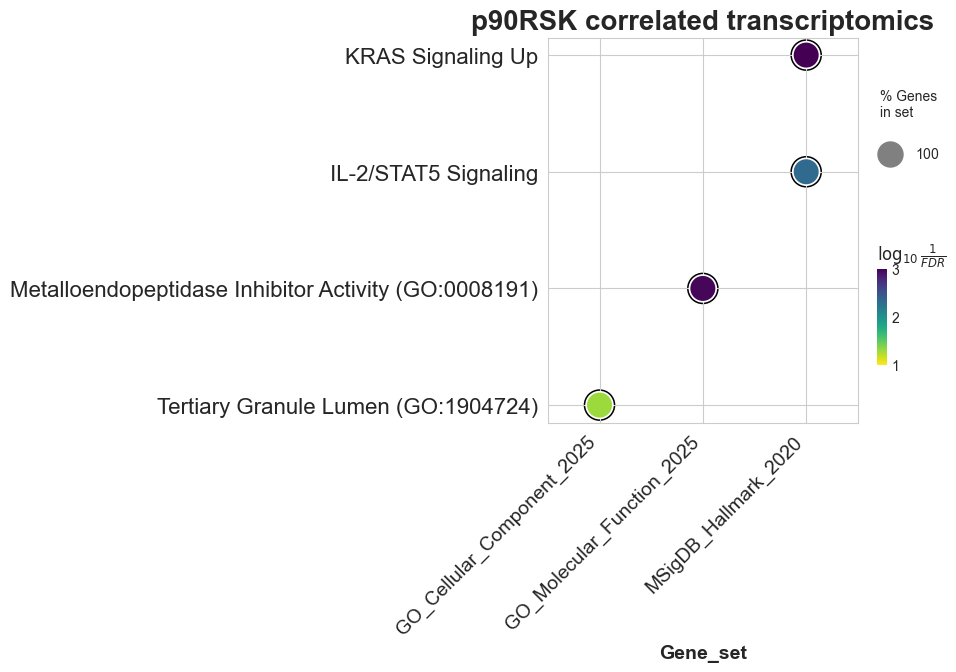

In [48]:
ax = gp.dotplot(
    enr_tx.results,
    column="Adjusted P-value",
    x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
    size=3,
    figsize=(5,5),
    title = "p90RSK correlated transcriptomics",
    xticklabels_rot=45, # rotate xtick labels
    show_ring=True, # set to False to remove outer ring
    marker='o',
)

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/gseapy/plot.py:753: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda _x: _x.sort_values(by=self.colname).tail(self.n_terms))


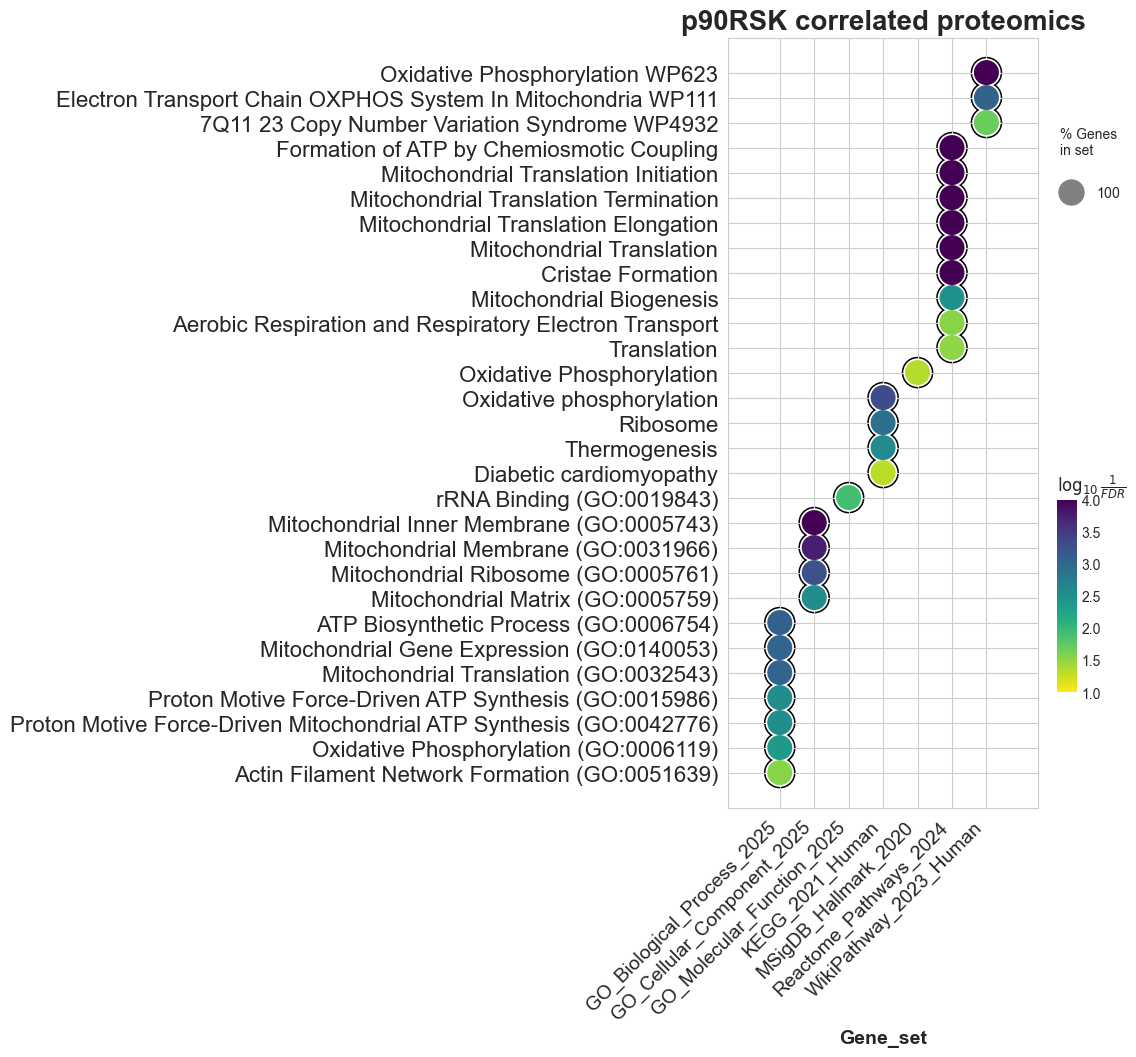

In [49]:
ax = gp.dotplot(
    enr_px.results,
    column="Adjusted P-value",
    x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
    size=3,
    figsize=(5,10),
    title = "p90RSK correlated proteomics",
    xticklabels_rot=45, # rotate xtick labels
    show_ring=True, # set to False to remove outer ring
    marker='o',
)

In [50]:
gl_t

['ACTBL2',
 'ATP11B',
 'CCDC78',
 'CCDC87',
 'CDC14B',
 'CERS6',
 'CHST8',
 'CIB2',
 'CLIP4',
 'CNN3',
 'CNPPD1',
 'COL18A1',
 'CP',
 'CTSS',
 'DNAJC14',
 'EME2',
 'ETS1',
 'ETV4',
 'FAHD1',
 'FPGT',
 'GHR',
 'GJA5',
 'GLIPR2',
 'GPRC5B',
 'GPRIN2',
 'HABP4',
 'HLA.DMB',
 'KIAA1257',
 'LCMT2',
 'LIF',
 'MAP3K8',
 'MRPS33',
 'NAB1',
 'PARD6G',
 'PAX6',
 'PIGR',
 'PLS3',
 'PPP1R10',
 'PXDC1',
 'QSOX1',
 'RARRES1',
 'RCAN1',
 'RECK',
 'RNF41',
 'S100A5',
 'SIGLEC15',
 'SMOX',
 'TBC1D1',
 'TBCA',
 'TGM2',
 'TIMP2',
 'TMEM63C',
 'TRIAP1',
 'TSPAN2',
 'UACA',
 'UBASH3B',
 'ZSCAN32']

In [65]:
import mygene

def symbols_to_uniprot(symbols):
    """
    Convert HGNC gene symbols (e.g. EGFR) to UniProt accessions.
    Returns a dict: {symbol: [uniprot IDs] or None}
    """
    mg = mygene.MyGeneInfo()
    res = mg.querymany(
        symbols,
        scopes="symbol",                # search by HGNC gene symbol
        fields="uniprot.Swiss-Prot",
        species="human"                 # restrict to human
    )

    mapping = {}
    for r in res:
        sym = r["query"]
        if "notfound" in r and r["notfound"]:
            mapping[sym] = None
        else:
            ids = []
            uniprot_field = r.get("uniprot", {})
            if isinstance(uniprot_field, dict):
                # could have 'Swiss-Prot' and/or 'TrEMBL', which may be str or list
                for sub in ["Swiss-Prot", "TrEMBL"]:
                    val = uniprot_field.get(sub)
                    if val:
                        ids.extend(val if isinstance(val, list) else [val])
            elif isinstance(uniprot_field, str):
                ids.append(uniprot_field)
            mapping[sym] = ids if ids else None
    return mapping

INFO:biothings.client:querying 1-1 ...
INFO:biothings.client:Finished.


['P00533']

In [84]:
import omnipath
op = omnipath.interactions.PostTranslational()
df_ptm = op.get()
erbb_upids = [upid for upids in symbols_to_uniprot(['EGFR', 'ERBB2']).values() for upid in upids if upids]
erbb_upids

INFO:biothings.client:querying 1-2 ...
INFO:biothings.client:Finished.


['P00533', 'P04626']

In [72]:
upid_t = symbols_to_uniprot(gl_t)
upid_p = symbols_to_uniprot(gl_p)

INFO:biothings.client:querying 1-57 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-53 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


In [74]:
upid_p.values()

dict_values([None, None, None, None, None, None, None, None, None, None, ['Q52LW3'], ['P25705'], ['P06576'], ['P30049'], ['O75964'], ['P24539'], ['Q8N8Y2'], ['Q86X02'], ['Q14011'], ['Q9NUL7'], ['Q969X5'], ['Q6P587'], None, ['P48507'], ['Q9UKN8'], ['Q9BW19'], ['P56270'], ['Q9NX20'], ['Q9H0U6'], ['P49406'], ['Q9BYC9'], ['Q9P0M9'], ['P09001'], ['Q9BQC6'], ['Q9BYD2'], ['P80297'], ['Q9UBB6'], ['O14777'], ['O96000'], ['Q9UNZ2'], ['Q9BQG2'], ['Q9ULD0'], ['Q14651'], ['P13797'], ['Q6IQ22'], ['Q9Y3L5'], ['Q8IXI1'], ['P51812'], ['Q14108'], ['Q9UNE7'], ['Q03519'], ['Q96A57'], ['P18206']])

In [85]:
df_ptm[
    (df_ptm['target'].isin(erbb_upids))
    &
    (df_ptm['source'].isin([upid for upids in upid_t.values() if upids for upid in upids]))
]

,source,target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,curation_effort,references,sources,n_sources,n_primary_sources,n_references,references_stripped
97123,Q9H4P4,P00533,True,False,True,True,False,True,0,NaN,Wang,1,1,None,None
111817,P43268,P04626,True,False,True,True,False,True,0,NaN,Wang,1,1,None,None
119854,P21980,P00533,True,True,False,True,True,False,0,NaN,Wang,1,1,None,None
127265,Q9H4P4,P04626,True,True,False,True,True,False,0,NaN,Wang,1,1,None,None


In [86]:
df_ptm[
    (df_ptm['target'].isin(erbb_upids))
    &
    (df_ptm['source'].isin([upid for upids in upid_p.values() if upids for upid in upids]))
]

,source,target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,curation_effort,references,sources,n_sources,n_primary_sources,n_references,references_stripped
31509,Q9UNE7,P04626,True,False,True,True,False,True,8,Cellinker:21710689;HINT:12239347;HINT:12574167...,Cellinker;HINT;HPRD;SIGNOR,4,4,5,12239347;12574167;17239458;17875712;21710689


In [52]:
cp = omnipath.requests.Complexes()
egfr_cp = set([gs for gsl in cp.complex_genes('EGFR')['components_genesymbols'].str.split('_').tolist() for gs in gsl])

In [56]:
egfr_t = [g for g in egfr_cp if g in gl_t]
egfr_t

['ETS1', 'MAP3K8', 'GHR', 'LIF']

In [57]:
egfr_p = [g for g in egfr_cp if g in gl_p]
egfr_p

['STUB1', 'ATP5PB', 'ATP5F1B', 'ATP5F1A']

In [58]:
cp.complex_genes('EGFR')[cp.complex_genes('EGFR').apply(lambda x: any(g in x['components_genesymbols'].split('_') for g in gl_t), axis=1)]

,name,components,components_genesymbols,stoichiometry,sources,references,identifiers,n_sources,n_primary_sources,n_references,references_stripped
20,JAK-STAT-Core,O60674_O75462_P00533_P01236_P01241_P01562_P015...,CNTF_CNTFR_CRLF1_CRLF2_CSF1_CSF2_CSF2RA_CSF3_C...,1:1:1:1:1:2:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:...,Compleat,None,Compleat:HC2503,1,1,None,None
27,EGF-Core,O14511_O14654_O14733_O15264_O43283_O43318_O755...,AREG_ATF1_ATF2_BRAF_BTC_CDC42_CREB1_CRK_DDIT3_...,1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:1:...,Compleat,None,Compleat:HC2002,1,1,None,None


In [59]:
cp.complex_genes('EGFR')[cp.complex_genes('EGFR').apply(lambda x: any(g in x['components_genesymbols'].split('_') for g in gl_p), axis=1)]

,name,components,components_genesymbols,stoichiometry,sources,references,identifiers,n_sources,n_primary_sources,n_references,references_stripped
16,None,P00533_P07900_P08238_P0DMV9_P11142_P25685_P319...,CDC37_DNAJB1_EGFR_HSP90AA1_HSP90AB1_HSPA1B_HSP...,1:1:1:1:1:1:1:1:1:1:1:1:1:1:1,Compleat;NetworkBlast,None,Compleat:HC6704,2,2,None,None
69,None,O75947_P00533_P06576_P24539_P25705_P36542_P480...,ATP5F1A_ATP5F1B_ATP5F1C_ATP5F1E_ATP5MF_ATP5PB_...,1:1:1:1:1:1:1:1:1:1,Compleat;NetworkBlast,None,Compleat:HC9763,2,2,None,None
